## Stars and Distant Objects - Skyfield API reference

Skyfield can generate positions for stars or and other distant objects that you either load from a star catalog, or else for which you can provide barycentric ICRS coordinates.

### The Hipparcos Catalog

One of the most popular star catalogs is the Hipparcos catalog, compiled from the observations of a 1989–1993 European Space Agency satellite telescope. The spelling is deliberate; the ancient Greek astronomer’s name was “Hipparchus” but the name of the observatory and resulting catalog are an acronym for “High Precision Parallax Collecting Satellite.”

To load this large star catalog with Skyfield requires the Pandas data library. If you use the Anaconda scientific Python distribution, you can install Pandas with:



In [1]:
# !conda install pandas

Otherwise you can try installing it with either the standard pip Python package installation tool:

In [2]:
# !pip install pandas

Whichever way you install it, the Pandas library gives Skyfield the ability to load the Hipparcos catalog as a 118,218 row Pandas dataframe. You can filter individual stars out of the dataframe using the Pandas loc[] operation with the star’s Hipparcos catalog number. For example, Barnard’s Star — the star moving fastest across our sky — has the Hipparcos designation “HIP 87937” and would be accessed like this:

In [3]:
from skyfield.api import Star, load
from skyfield.data import hipparcos

with load.open(hipparcos.URL) as f:
    df = hipparcos.load_dataframe(f)

barnards_star = Star.from_dataframe(df.loc[87937])

To generate the position of a star in the Earth’s sky on a given date, compute the Earth’s position in the Solar System and then ````observe()```` the star:

In [4]:
planets = load('de421.bsp')
earth = planets['earth']

ts = load.timescale()
t = ts.now()
astrometric = earth.at(t).observe(barnards_star)
ra, dec, distance = astrometric.radec()
print(f'ra is: {ra}')
print(f'dec is: {dec}')

ra is: 17h 57m 47.10s
dec is: +04deg 46' 01.3"


The position will properly reflect the star’s proper motion as measured by the HIPPARCOS mission.

### Looking up specific stars

We looked up Barnard’s Star in the above example using its Hipparcos catalog number, HIP 87937. If your project targets several specific stars, you can learn their HIP catalog numbers through any number of online search engines. Here is a popular choice:

https://vizier.u-strasbg.fr/viz-bin/VizieR?-source=1239/hip_main

General-purpose references like the Wikipedia also tend to supply HIP numbers when describing a star, so searching a star’s page for the acronym “HIP” is also likely to lead you to its Hipparcos number.

### Stars with “nan” positions
The Hipparcos catalog, as pointed out in its official publication The Hipparcos and Tycho Catalogues, includes 263 target stars for which no reliable position could be computed. These stars have blanks for their right ascension and declination in the text of the catalog itself. In Skyfield they will always return coordinates with the value nan (the floating point value “not a number”).

If you want to avoid nan coordinates, you can filter them out of your dataframe with:

In [5]:
df = df[df['ra_degrees'].notnull()]

The result will be the same if you filter by the ````dec_degrees```` column instead.

### Filtering the star catalog

In addition to selecting individual stars using their HIP number, you can build a Star object that contains all of the stars in a dataframe. You can combine this with the standard Pandas dataframe filtering techniques to select only stars above a certain brightness.

For example, let’s imagine that we wanted to plot the stars in the constellation Orion — but only stars that are at least magnitude 2.5. Pandas will let us filter the Hipparcos catalog dataframe in a single line of code:

In [6]:
df = df[df['magnitude'] <= 2.5]
print(f'After filtering, there are {len(df)} stars')

After filtering, there are 93 stars


You can use this dataframe to build a Star object that will compute the positions of all 93 stars at once.

In [7]:
bright_stars = Star.from_dataframe(df)

t = ts.utc(2018, 9, 3)
astrometric = earth.at(t).observe(bright_stars)
ra, dec, distance = astrometric.radec()

print(f'There are {len(ra.hours)} right ascensions')
print(f'and {len(dec.degrees)} declinations')

There are 93 right ascensions
and 93 declinations


Each element of the right ascension array and the declination array corresponds to one of the 93 selected stars. Their position can be combined with their magnitude to produce a plot.


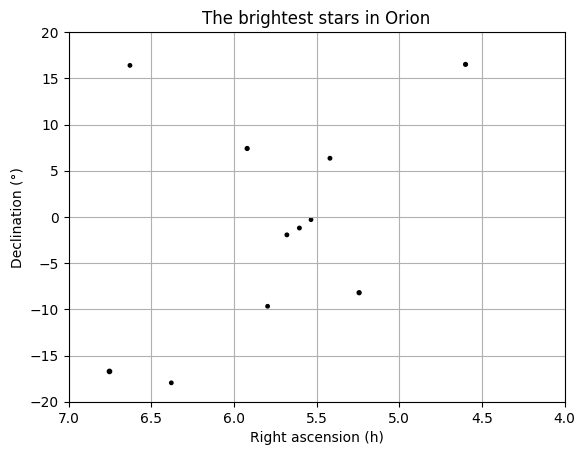

In [8]:
from matplotlib import pyplot as plt

fig, ax = plt.subplots()
ax.scatter(ra.hours, dec.degrees, 8 - df['magnitude'], 'k')
ax.set_xlim(7.0, 4.0)
ax.set_ylim(-20, 20)
ax.grid(True)
ax.set(title='The brightest stars in Orion',
       xlabel='Right ascension (h)', ylabel='Declination (°)')
fig.savefig('bright_stars.png')

The result of the simple filtering and plotting is an (admittedly primitive) rendering of Orion!


For a more complete example of code that draws a star chart, see [Drawing a finder chart for comet NEOWISE](https://rhodesmill.org/skyfield/example-plots.html#neowise-chart).

### Building a single star from its coordinates
If instead of loading up a whole star catalog you have the coordinates for one particular star you are interested in, you can instantiate a Star directly using keyword arguments. Right ascension and declination can be specified as traditional base-60 coordinates, where the fractions are “minutes” and “seconds”, if you pass tuples instead of floats:

In [9]:
from skyfield.api import Star, load
planets = load('de421.bsp')
earth = planets['earth']

barnard = Star(ra_hours=(17, 57, 48.49803),
               dec_degrees=(4, 41, 36.2072))

ts = load.timescale()
t = ts.now()
astrometric = earth.at(t).observe(barnard)
ra, dec, distance = astrometric.radec()
print(f'ra is: {ra}')
print(f'dec is: {dec}')

ra is: 17h 57m 48.50s
dec is: +04deg 41' 36.2"


Of course, this has simply returned the same position. More interesting is that we can ask for the position to be expressed in the dynamical reference system of the moving Earth instead of in the same fixed ICRS system in which we provided it:

In [10]:
ra, dec, distance = astrometric.radec(epoch=ts.now())
print(f'ra is: {ra}')
print(f'dec is: {dec}')

ra is: 17h 59m 04.81s
dec is: +04deg 41' 23.4"


### Distances to stars
The distance that Skyfield computes to a particular star might or might not be meaningful, depending both on which star catalog you are using and on which particular star you observe.

Skyfield has no way to even guess the distance to a star if it has only been given its right ascension and declination, as is the case for Barnard’s Star as we defined it above. To represent this vector of unknown length, Skyfield generates a vector exactly one gigaparsec long:

In [11]:
print(f'{distance} is exactly 1 gigaparsec')  # exactly 1 gigaparsec

2.06265e+14 au is exactly 1 gigaparsec


This is so very far outside of our galaxy that such positions should be easy for you to tell apart from real distances to stars. Real distances will all be within a few hundred parsecs or less, because our telescopes cannot currently measure the parallax of stars that are any further away than that.

In the next section, we will redefine Barnard’s Star and this time supply a real value for its parallax from a recent star catalog. You will see in that its distance switches to a realistic estimate.



### Proper motion and parallax
There are other ways that a Star object can generate a position different than the plain old ICRS right ascension and declination with which it is initialized. First, Skyfield will recognize that an object should change position over the years if we specify its proper motion in milliarcseconds (“mas”) per year. Second, Skyfield will shift its apparent position relative to the location from which you observe it if you provide a parallax indicating that the star is close enough to the Solar System that we have been able to measure its distance. Finally, there is even a tiny effect from its radial velocity if it is known.

Here are all three effects applied to Barnard’s star:

In [12]:
barnard = Star(ra_hours=(17, 57, 48.49803),
               dec_degrees=(4, 41, 36.2072),
               ra_mas_per_year=-798.71,
               dec_mas_per_year=+10337.77,
               parallax_mas=545.4,
               radial_km_per_s=-110.6)

astrometric = earth.at(t).observe(barnard)
ra, dec, distance = astrometric.radec()
print(f'ra is: {ra}')
print(f'dec is: {dec}')
print(f'distance is: {distance}')

ra is: 17h 57m 47.09s
dec is: +04deg 46' 01.9"
distance is: 3.77592e+05 au


Note that the above position is different than the input right ascension and declination but not because we have asked for dynamic coordinates. This position is in fixed ICRS coordinates and indicates real motion on the part of Barnard’s star across our sky.

See the guide to [Positions](https://rhodesmill.org/skyfield/positions.html) to learn the operations that you can perform with these astrometric positions after using a [Star](https://rhodesmill.org/skyfield/api-stars.html#skyfield.starlib.Star) object to generate them.

### Position at an epoch besides J2000
Some star catalogs provide positions at an epoch besides J2000. For example, the catalog of stars observed by the Hipparcos space telescope provides their positions as of J1991.25.

The epoch can be provided as an argument epoch to [Star](https://rhodesmill.org/skyfield/api-stars.html#skyfield.starlib.Star). Here are the right ascension and declination given for Barnard’s Star in the Hipparcos catalog:

In [13]:
hipparcos_epoch = ts.tt(1991.25)
barnard2 = Star(ra_hours=(17, 57, 48.97),
                dec_degrees=(4, 40, 5.8),
                ra_mas_per_year=-797.84,
                dec_mas_per_year=+10326.93,
                epoch=hipparcos_epoch)

ra, dec, distance = earth.at(t).observe(barnard2).radec()
print(f'ra is: {ra}')
print(f'dec is: {dec}')
print(f'distance is: {distance}')

ra is: 17h 57m 47.13s
dec is: +04deg 46' 01.1"
distance is: 2.06265e+14 au


As you can see, the position returned for the date t is the same, even though we initialized this Star object with a position for Barnard’s Star more than 8 years earlier than the position we used in our first example.